In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import cmasher as cmr

from utils import f_sm, sample_X
from models import CondSM

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

state_dict_0 = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_uni_0/sm_uni_0.pth', weights_only=False, map_location='cpu')
model_0 = CondSM(state_dict_0['layer_dims'], dropout_p=state_dict_0['dropout'], batch_norm=state_dict_0['batch_norm'])
model_0.load_state_dict(state_dict_0['model_state_dict'])

state_dict_1 = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_uni_1/sm_uni_1.pth', weights_only=False, map_location='cpu')
model_1 = CondSM(state_dict_1['layer_dims'], dropout_p=state_dict_1['dropout'], batch_norm=state_dict_1['batch_norm'])
model_1.load_state_dict(state_dict_1['model_state_dict'])

print('models loaded')

cuda
models loaded


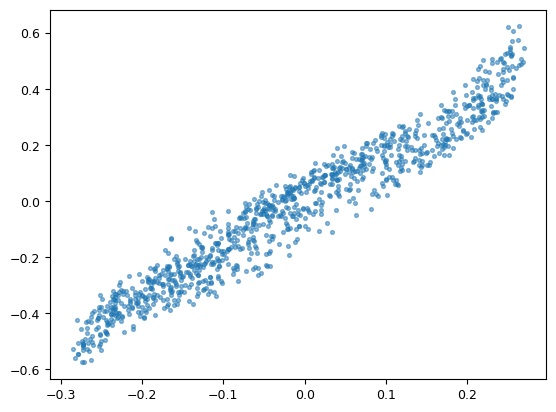

In [41]:
input_idx = 0
N = 1000
thetas = sample_X(N, d=7)
#v_range = torch.linspace(-1.5, 1.5, N).unsqueeze(-1)
#input_tensor = torch.cat([v_range, thetas], axis=1)

y_0 = f_sm(thetas, model_0)
y_1 = f_sm(thetas, model_1)
plt.scatter(y_0, y_1, s=7.5, alpha=0.5)